# Лабораторная работа №4

**Тема:** Вычисление и визуализация морфологического спектра для бинарных и полутоновых изображений

**Студент:** Косило Павел Андреевич

## 1. Теоретическая справка

Морфологический спектр, или функция распределения размеров, позволяет количественно описать характерные размеры объектов и структур на изображении.

Для бинарного изображения спектр определяется через последовательные отмыкания и замыкания структурирующим элементом $B$:

$$
PS_X(n, B) = A((X \circ nB) \setminus (X \circ (n + 1)B)), \quad n \ge 0
$$

$$
PS_X(-n, B) = A((X \bullet nB) \setminus (X \bullet (n - 1)B)), \quad n \ge 1
$$

Для полутонового изображения вместо площади множества используется сумма значений яркости пикселей:

$$
PS_f(+n, g) = A((f \circ ng) - (f \circ (n + 1)g)), \quad 0 \le n \le N
$$

$$
PS_f(-n, g) = A((f \bullet ng) - (f \bullet (n - 1)g)), \quad 1 \le n \le K
$$

В программе структурирующий элемент передаётся в функцию как аргумент, а масштаб $n$ реализуется итерационным повторением эрозии и дилатации базовым элементом. Это позволяет вычислять спектры для разных форм структурирующих элементов без изменения основной логики алгоритма.

## 2. Исходные изображения

В работе используются два синтетических изображения, которые генерируются программно и не требуют загрузки внешних файлов:

1. **Бинарное изображение** с набором кругов разных радиусов.
2. **Полутоновое изображение** с несколькими плавными яркостными максимумами, сформированными суммой двумерных гауссовых функций.

Для демонстрации вычисления спектра применяются два структурирующих элемента: крест `3x3` и квадрат `3x3`. При этом код позволяет передавать в вычислительную функцию любой другой структурирующий элемент в качестве аргумента.

## 3. Код программы

Ниже приведён код, который:

1. Генерирует бинарное и полутоновое изображения.
2. Вычисляет морфологический спектр для переданного структурирующего элемента.
3. Строит спектры для нескольких структурирующих элементов.
4. Выводит численные характеристики и визуализирует результаты.

Используемые структурирующие элементы:
Крест 3x3:
[[0 1 0]
 [1 1 1]
 [0 1 0]]

Квадрат 3x3:
[[1 1 1]
 [1 1 1]
 [1 1 1]]

Количество пикселей бинарного изображения: 40596
Сумма яркостей полутонового изображения: 6394922

Бинарное изображение, Крест 3x3: максимум спектра при n = 19, значение = 2705
Бинарное изображение, Квадрат 3x3: максимум спектра при n = 22, значение = 6572
Полутоновое изображение, Крест 3x3: максимум спектра при n = 24, значение = 20432
Полутоновое изображение, Квадрат 3x3: максимум спектра при n = 24, значение = 54024


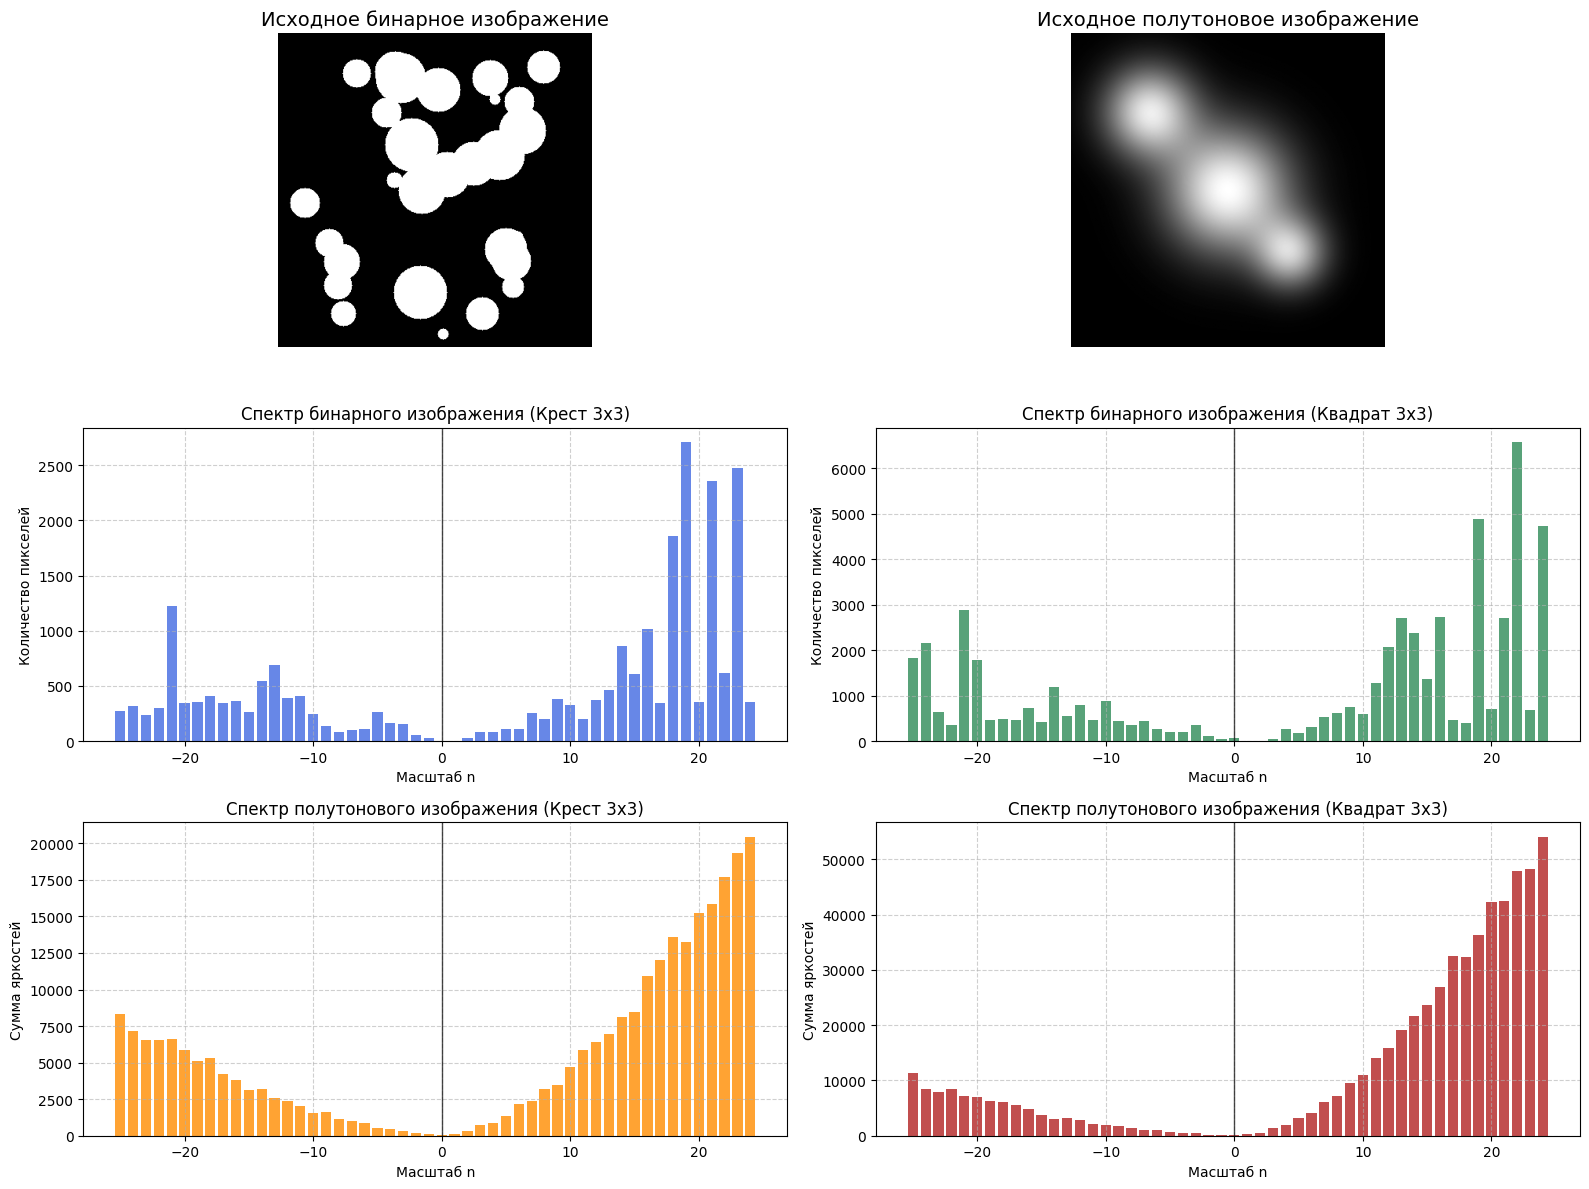

In [2]:
import importlib
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "cv2": "opencv-python",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
}

for module_name, package_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        importlib.invalidate_caches()

cv2 = importlib.import_module("cv2")
np = importlib.import_module("numpy")
plt = importlib.import_module("matplotlib.pyplot")

def create_binary_test_image(seed=42, image_size=400, object_count=30):
    """Создает бинарное изображение с кругами разных радиусов."""
    rng = np.random.default_rng(seed)
    image = np.zeros((image_size, image_size), dtype=np.uint8)

    for _ in range(object_count):
        radius = int(rng.integers(5, 35))
        x_coord = int(rng.integers(radius, image_size - radius))
        y_coord = int(rng.integers(radius, image_size - radius))
        cv2.circle(image, (x_coord, y_coord), radius, 255, -1)

    return image

def create_gray_test_image(image_size=400):
    """Создает полутоновое изображение как сумму нескольких гауссовых максимумов."""
    x_values = np.linspace(-10, 10, image_size)
    y_values = np.linspace(-10, 10, image_size)
    x_grid, y_grid = np.meshgrid(x_values, y_values)

    gaussian_1 = 200 * np.exp(-((x_grid) ** 2 + (y_grid) ** 2) / 15)
    gaussian_2 = 150 * np.exp(-((x_grid - 4) ** 2 + (y_grid - 4) ** 2) / 5)
    gaussian_3 = 180 * np.exp(-((x_grid + 5) ** 2 + (y_grid + 5) ** 2) / 8)

    image = np.clip(gaussian_1 + gaussian_2 + gaussian_3, 0, 255).astype(np.uint8)
    return image

def apply_iterated_morphology(image, structuring_element, repetitions, operation):
    """Выполняет n-кратное отмыкание или замыкание базовым структурирующим элементом."""
    if repetitions == 0:
        return image.copy()

    if operation == "open":
        eroded = cv2.erode(image, structuring_element, iterations=repetitions)
        return cv2.dilate(eroded, structuring_element, iterations=repetitions)

    if operation == "close":
        dilated = cv2.dilate(image, structuring_element, iterations=repetitions)
        return cv2.erode(dilated, structuring_element, iterations=repetitions)

    raise ValueError("operation must be 'open' or 'close'")

def measure_image(image, is_binary):
    """Возвращает площадь бинарного изображения или сумму яркостей полутонового."""
    if is_binary:
        return float(cv2.countNonZero(image))
    return float(np.sum(image, dtype=np.float64))

def compute_morphological_spectrum(image, structuring_element, max_scale, is_binary=True):
    """Вычисляет морфологический спектр для заданного структурирующего элемента."""
    opening_areas = []
    closing_areas = []

    for scale in range(max_scale + 1):
        opened = apply_iterated_morphology(image, structuring_element, scale, "open")
        closed = apply_iterated_morphology(image, structuring_element, scale, "close")
        opening_areas.append(measure_image(opened, is_binary))
        closing_areas.append(measure_image(closed, is_binary))

    positive_branch = np.array(
        [opening_areas[scale] - opening_areas[scale + 1] for scale in range(max_scale)],
        dtype=np.float64,
    )
    negative_branch = np.array(
        [closing_areas[scale + 1] - closing_areas[scale] for scale in range(max_scale)],
        dtype=np.float64,
    )

    positive_branch = np.maximum(positive_branch, 0)
    negative_branch = np.maximum(negative_branch, 0)

    scale_values = np.concatenate((np.arange(-max_scale, 0), np.arange(0, max_scale)))
    spectrum_values = np.concatenate((negative_branch[::-1], positive_branch))

    return scale_values, spectrum_values

def summarize_spectrum(scale_values, spectrum_values):
    """Возвращает положение и величину доминирующего пика спектра."""
    dominant_index = int(np.argmax(spectrum_values))
    return int(scale_values[dominant_index]), float(spectrum_values[dominant_index])

def plot_spectrum(ax, scale_values, spectrum_values, title, color, y_label):
    """Строит столбчатую диаграмму морфологического спектра."""
    ax.bar(scale_values, spectrum_values, width=0.8, color=color, alpha=0.8)
    ax.axvline(0, color="black", linewidth=1, alpha=0.7)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Масштаб n")
    ax.set_ylabel(y_label)
    ax.grid(True, linestyle="--", alpha=0.6)

binary_image = create_binary_test_image()
gray_image = create_gray_test_image()

structuring_elements = {
    "Крест 3x3": cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3)),
    "Квадрат 3x3": cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)),
}

max_scale = 25
binary_spectra = {}
gray_spectra = {}

for element_name, element in structuring_elements.items():
    binary_spectra[element_name] = compute_morphological_spectrum(
        binary_image, element, max_scale, is_binary=True
    )
    gray_spectra[element_name] = compute_morphological_spectrum(
        gray_image, element, max_scale, is_binary=False
    )

print("Используемые структурирующие элементы:")
for element_name, element in structuring_elements.items():
    print(f"{element_name}:")
    print(element)
    print()

print(f"Количество пикселей бинарного изображения: {int(np.count_nonzero(binary_image))}")
print(f"Сумма яркостей полутонового изображения: {int(np.sum(gray_image, dtype=np.int64))}")
print()

for element_name, (scale_values, spectrum_values) in binary_spectra.items():
    dominant_scale, dominant_value = summarize_spectrum(scale_values, spectrum_values)
    print(
        f"Бинарное изображение, {element_name}: максимум спектра при n = {dominant_scale}, значение = {dominant_value:.0f}"
    )

for element_name, (scale_values, spectrum_values) in gray_spectra.items():
    dominant_scale, dominant_value = summarize_spectrum(scale_values, spectrum_values)
    print(
        f"Полутоновое изображение, {element_name}: максимум спектра при n = {dominant_scale}, значение = {dominant_value:.0f}"
    )

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

axes[0, 0].imshow(binary_image, cmap="gray")
axes[0, 0].set_title("Исходное бинарное изображение", fontsize=14)
axes[0, 0].axis("off")

axes[0, 1].imshow(gray_image, cmap="gray")
axes[0, 1].set_title("Исходное полутоновое изображение", fontsize=14)
axes[0, 1].axis("off")

binary_colors = {
    "Крест 3x3": "royalblue",
    "Квадрат 3x3": "seagreen",
}
gray_colors = {
    "Крест 3x3": "darkorange",
    "Квадрат 3x3": "firebrick",
}

for axis, (element_name, (scale_values, spectrum_values)) in zip(axes[1], binary_spectra.items()):
    plot_spectrum(
        axis,
        scale_values,
        spectrum_values,
        f"Спектр бинарного изображения ({element_name})",
        binary_colors[element_name],
        "Количество пикселей",
    )

for axis, (element_name, (scale_values, spectrum_values)) in zip(axes[2], gray_spectra.items()):
    plot_spectrum(
        axis,
        scale_values,
        spectrum_values,
        f"Спектр полутонового изображения ({element_name})",
        gray_colors[element_name],
        "Сумма яркостей",
    )

plt.tight_layout()
plt.show()

## 4. Результат работы программы

После выполнения кода формируются два исходных изображения, четыре гистограммы морфологического спектра и текстовый вывод с численными характеристиками результата.

1. **Верхняя строка** содержит исходное бинарное и исходное полутоновое изображения.
2. **Средняя строка** показывает спектры бинарного изображения для структурирующих элементов Крест `3x3` и Квадрат `3x3`.
3. **Нижняя строка** показывает спектры полутонового изображения для тех же структурирующих элементов.
4. **Текстовый вывод** содержит матрицы структурирующих элементов, базовые числовые характеристики изображений и положение доминирующих пиков спектра.

**Анализ результата:** для бинарного изображения спектр имеет выраженные пики, соответствующие характерным размерам сгенерированных объектов. Для полутонового изображения спектр получается более плавным, так как яркость изменяется непрерывно. Изменение формы структурирующего элемента влияет на положение и величину пиков, что подтверждает зависимость морфологического спектра от выбранного элемента.